Упражнение 26.1 Решить в целых числах с помощь пакета lpSolve применяя метод ветвей и границ интерактивно.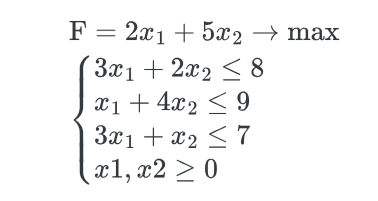

In [9]:
import numpy as np
from scipy.optimize import linprog

c = [-2, -5]

A = [
    [3, 2],
    [1, 4],
    [3, 1]
]

b = [8, 9, 7]

bounds_root = [(0, None), (0, None)]


In [10]:


res_root = linprog(c, A_ub=A, b_ub=b, bounds=bounds_root, method='highs')

print("=== Шаг 1: Корневой узел (непрерывное решение) ===")
print("Статус (0 означает успех):", res_root.status)
print(f"x1 = {res_root.x[0]:.2f}")
print(f"x2 = {res_root.x[1]:.2f}")
print(f"Максимум F = {-res_root.fun:.2f}")

=== Шаг 1: Корневой узел (непрерывное решение) ===
Статус (0 означает успех): 0
x1 = 1.40
x2 = 1.90
Максимум F = 12.30


In [11]:
# x1 >= 0 (без изменений)
# x2 >= 2 (наше новое ограничение для ветвления)
bounds_branch2 = [(0, None), (2, None)]

res_branch2 = linprog(c, A_ub=A, b_ub=b, bounds=bounds_branch2, method='highs')

print("=== Шаг 2: Ветвь 2 (x2 >= 2) ===")
if res_branch2.success:
    print(f"x1 = {res_branch2.x[0]:.2f}")
    print(f"x2 = {res_branch2.x[1]:.2f}")
    print(f"Значение F = {-res_branch2.fun:.2f}")
else:
    print("Решение не найдено (система ограничений несовместна)")

=== Шаг 2: Ветвь 2 (x2 >= 2) ===
x1 = 1.00
x2 = 2.00
Значение F = 12.00


In [12]:
# x1 >= 0 (без изменений)
# x2 <= 1 (новое ограничение, диапазон от 0 до 1)
bounds_branch1 = [(0, None), (0, 1)]

res_branch1 = linprog(c, A_ub=A, b_ub=b, bounds=bounds_branch1, method='highs')

print("=== Шаг 3: Ветвь 1 (x2 <= 1) ===")
if res_branch1.success:
    print(f"x1 = {res_branch1.x[0]:.2f}")
    print(f"x2 = {res_branch1.x[1]:.2f}")
    print(f"Теоретический максимум F = {-res_branch1.fun:.2f}")
else:
    print("Решение не найдено")

record = -res_branch2.fun
if -res_branch1.fun <= record:
    print(f"\nВывод: Максимально возможное значение в Ветви 1 ({-res_branch1.fun:.2f})")
    print(f"не превышает наш текущий рекорд ({record:.2f}).")

=== Шаг 3: Ветвь 1 (x2 <= 1) ===
x1 = 2.00
x2 = 1.00
Теоретический максимум F = 9.00

Вывод: Максимально возможное значение в Ветви 1 (9.00)
не превышает наш текущий рекорд (12.00).


Упражнение 25.1 (Несчастливая сессия) Каждый год после весенней сессии министерство обороны решает задачу о распределении бывших студентов по родам войск. Стоимость транспортировки пропорциональная расстоянию до части. Определите план с наименьшей стоимостью.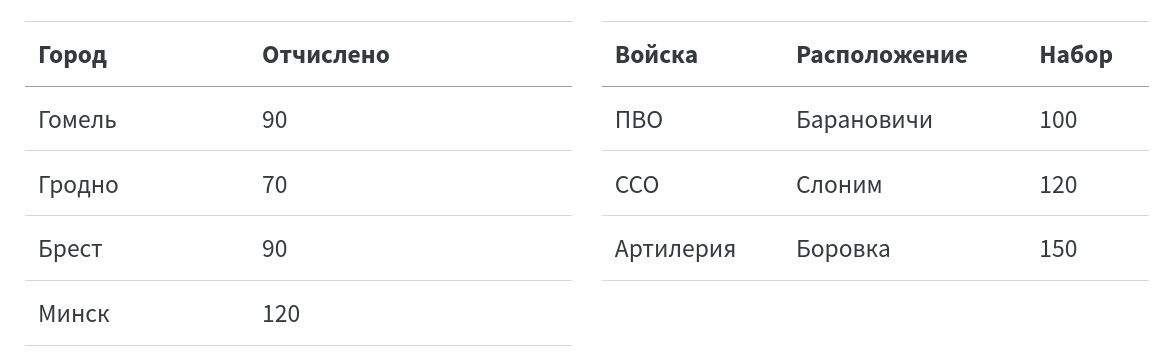
Справочно приводится таблица расстояний
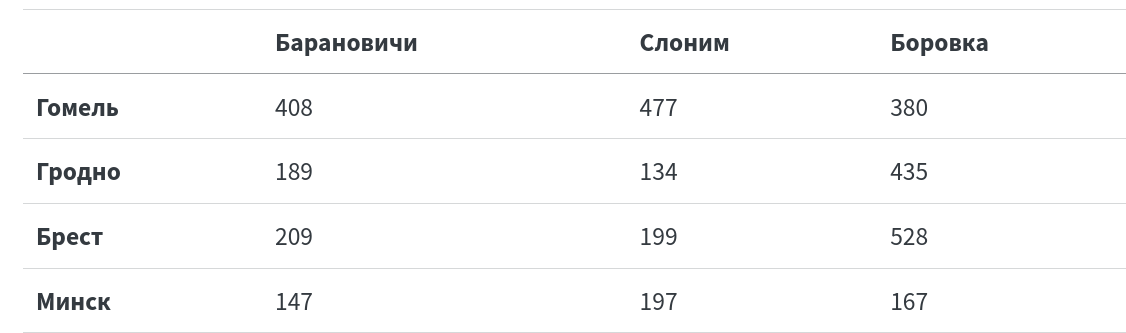

In [13]:
import numpy as np
from scipy.optimize import linprog

# Запасы (города: Гомель, Гродно, Брест, Минск)
supply = [90, 70, 90, 120]

# Потребности (части: Барановичи, Слоним, Боровка)
demand = [100, 120, 150]

# Матрица стоимостей
costs = [
    [408, 477, 380], # Гомель
    [189, 134, 435], # Гродно
    [209, 199, 528], # Брест
    [147, 197, 167]  # Минск
]

c = np.array(costs).flatten()

A_eq = []
b_eq = []

In [14]:
# Ограничения по запасам (отчисленным из городов)
for i in range(4):
    row = np.zeros(12)
    row[i*3 : (i+1)*3] = 1
    A_eq.append(row)
    b_eq.append(supply[i])

# Ограничения по потребностям (набору в части)
for j in range(3):
    row = np.zeros(12)
    for i in range(4):
        row[i*3 + j] = 1
    A_eq.append(row)
    b_eq.append(demand[j])

bounds = [(0, None) for _ in range(12)]

In [15]:

res = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')

print("=== Результаты распределения (Упражнение 25.1) ===")
print("Статус решения:", res.message)

if res.success:
    print(f"\nМинимальная суммарная стоимость (расстояние): {res.fun:.0f}\n")
    solution_matrix = np.array(res.x).reshape(4, 3)

    cities = ["Гомель", "Гродно", "Брест", "Минск"]
    bases = ["ПВО (Барановичи)", "ССО (Слоним)", "Артилерия (Боровка)"]

    for i in range(4):
        for j in range(3):
            val = round(solution_matrix[i][j])
            if val > 0:
                print(f"Из г. {cities[i]:<7} в {bases[j]:<20} -> отправлено {val} чел. (расстояние: {costs[i][j]})")
else:
    print("Решение не найдено.")

=== Результаты распределения (Упражнение 25.1) ===
Статус решения: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Минимальная суммарная стоимость (расстояние): 80730

Из г. Гомель  в Артилерия (Боровка)  -> отправлено 90 чел. (расстояние: 380)
Из г. Гродно  в ССО (Слоним)         -> отправлено 70 чел. (расстояние: 134)
Из г. Брест   в ПВО (Барановичи)     -> отправлено 40 чел. (расстояние: 209)
Из г. Брест   в ССО (Слоним)         -> отправлено 50 чел. (расстояние: 199)
Из г. Минск   в ПВО (Барановичи)     -> отправлено 60 чел. (расстояние: 147)
Из г. Минск   в Артилерия (Боровка)  -> отправлено 60 чел. (расстояние: 167)
